<a href="https://colab.research.google.com/github/rahulg202/loan-default-prediction/blob/main/model_z_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Aggregate GPS data: calculate mean accuracy and count of GPS fixes
gps_aggregates = gps_fixes.groupby('user_id').agg(
    mean_accuracy=('accuracy', 'mean'),
    num_gps_fixes=('gps_fix_at', 'count')
).reset_index()

# Display the first few rows
print(gps_aggregates.head())

   user_id  mean_accuracy  num_gps_fixes
0        1    1105.084571             70
1        2      48.596000             10
2        3       6.500000              1
3        4    2172.200000              2
4        5      43.461111              9


In [ ]:

loan_user_merge = pd.merge(loan_outcomes, user_attributes, on='user_id', how='inner')

merged_data = pd.merge(loan_user_merge, gps_aggregates, on='user_id', how='inner')

print("Number of records in merged dataset:", merged_data.shape[0])
print("Columns in merged dataset:", merged_data.columns)
print(merged_data.head())


Number of records in merged dataset: 372
Columns in merged dataset: Index(['user_id', 'application_at', 'loan_outcome', 'age',
       'cash_incoming_30days', 'mean_accuracy', 'num_gps_fixes'],
      dtype='object')
   user_id             application_at loan_outcome  age  cash_incoming_30days  \
0        1 2017-08-14 09:08:50.000000    defaulted   42               8988.12   
1        2 2016-05-17 10:10:12.447976       repaid   36               9968.12   
2        3 2016-10-20 10:07:20.459081    defaulted   27                 59.04   
3        4 2017-01-13 13:03:34.000000    defaulted   38               2129.03   
4        5 2016-11-03 15:41:39.124610       repaid   33               2102.53   

   mean_accuracy  num_gps_fixes  
0    1105.084571             70  
1      48.596000             10  
2       6.500000              1  
3    2172.200000              2  
4      43.461111              9  


In [ ]:
merged_data.isnull().sum()

,0
user_id,0
application_at,0
loan_outcome,0
age,0
cash_incoming_30days,0
mean_accuracy,0
num_gps_fixes,0


In [ ]:
merged_data.duplicated().sum()

0

In [ ]:
merged_data['loan_outcome'] = merged_data['loan_outcome'].map({'defaulted': 0, 'repaid': 1})
merged_data

,user_id,application_at,loan_outcome,age,cash_incoming_30days,mean_accuracy,num_gps_fixes
0,1,2017-08-14 09:08:50.000000,0,42,8988.12,1105.084571,70
1,2,2016-05-17 10:10:12.447976,1,36,9968.12,48.596000,10
2,3,2016-10-20 10:07:20.459081,0,27,59.04,6.500000,1
3,4,2017-01-13 13:03:34.000000,0,38,2129.03,2172.200000,2
4,5,2016-11-03 15:41:39.124610,1,33,2102.53,43.461111,9
...,...,...,...,...,...,...,...
367,396,2016-10-10 12:20:18.367328,0,29,1947.86,658.179032,31
368,397,2018-02-12 08:29:42.000000,0,28,6099.13,1110.642857,7
369,398,2016-08-30 11:01:41.879989,0,24,7136.95,9.066667,9
370,399,2016-09-11 08:14:06.034076,0,62,18043.21,65.030000,32


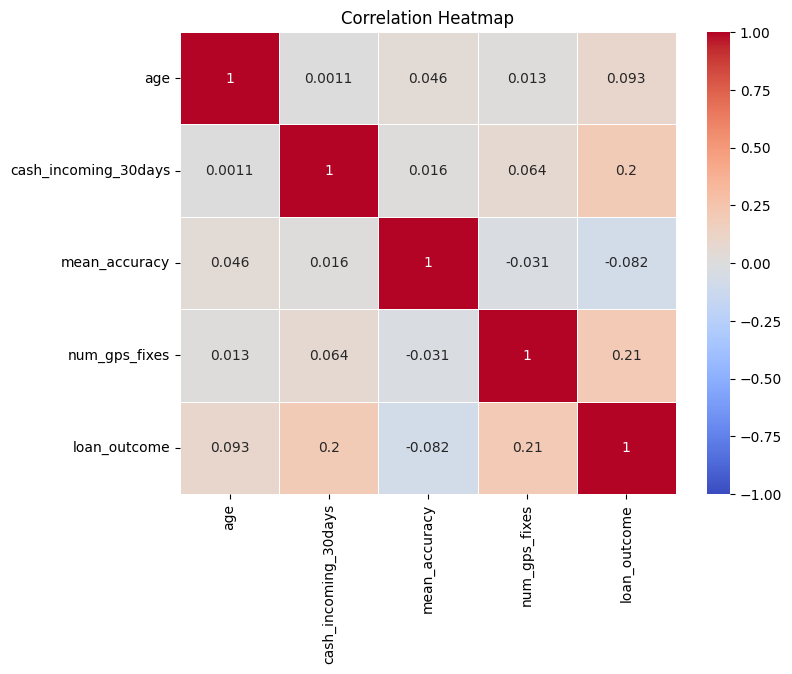

In [ ]:
# Select relevant numerical columns
correlation_columns = ['age', 'cash_incoming_30days', 'mean_accuracy', 'num_gps_fixes', 'loan_outcome']
# Calculate the correlation matrix
correlation_matrix = merged_data[correlation_columns].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

# Display the heatmap
plt.title('Correlation Heatmap')
plt.show()

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:13:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


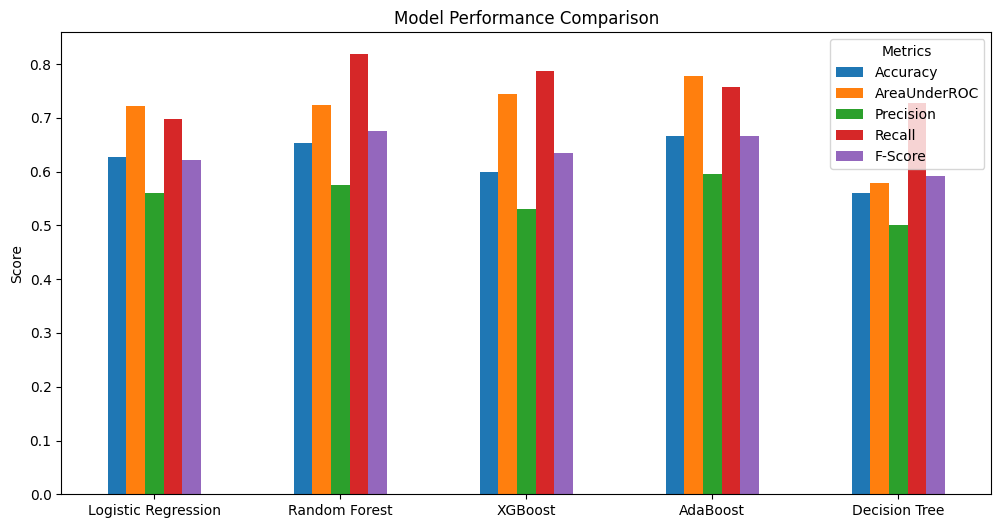

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

X = merged_data[['age', 'cash_incoming_30days', 'mean_accuracy', 'num_gps_fixes']]
y = merged_data['loan_outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'AdaBoost': AdaBoostClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'AreaUnderROC': roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F-Score': f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T

results_df.plot(kind='bar', figsize=(12, 6))
plt.xticks(rotation=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.legend(title='Metrics')
plt.show()